This notebook is used for testing the training of the integrated flow and transport model

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp
import jax.tree_util as jtu

import equinox as eqx 

import optax

from DiffFlowTransport.transport import SASTransport
from DiffFlowTransport.flow import LSTM
from DiffFlowTransport.utils import scale_df, make_pytorch_timeseries_dataloader
from DiffFlowTransport.utils import get_transport_obs_fluxes
from DiffFlowTransport.utils.plot import plot_timeseries_obs_1to1, plot_PQET_quantile
from DiffFlowTransport.utils.plot import plot_PQET_ST, plot_PQET_ST2, plot_young_water
from DiffFlowTransport.utils import train_flow_model, train_transport_model, mse, predict_dl
from DiffFlowTransport.sas import initialize_sas_model
from DiffFlowTransport.sas import get_sas_inputs, get_sas_inputs_amount
from DiffFlowTransport.model import load_model, save_model

import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
# %reload_ext autoreload


/home/bizon/Peishi/DiffFlowTransport/src/DiffFlowTransport/transport/sas_transport.py:20: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  solver: Callable = eqx.static_field()
/home/bizon/Peishi/DiffFlowTransport/src/DiffFlowTransport/transport/sas_transport.py:24: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  nm: int = eqx.static_field()
/home/bizon/Peishi/DiffFlowTransport/src/DiffFlowTransport/transport/sas_transport.py:25: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  τ_max: int = eqx.static_field()


# General configurations

In [2]:
# Watershed
watershed_name = 'OakCreek'

# Data option
data_option = 'withDiffusion'

# The flow and transport model coupling type
flow_transport_coupling_type = 1

# Label
model_label = f'mdn-gaussian-couplingtype{flow_transport_coupling_type}-logQ'


# Read the data

In [3]:
# f_data = f'./data_{data_option}.csv'
# f_data = f'./data_{data_option}_withSpinup.csv'
f_data = f'./data_{data_option}_withSpinup-correctedZeroFlow.csv'
df = pd.read_csv(f_data, index_col=0)
df.index = pd.to_datetime(df.index)
df.head()

,J,SNOW,SM,P,P2,ET,Tair,SWIN,Q,C_J,C_P,C_P2,C_P2b,C_Q
2004-10-03,0.022043,0.0,0.007034,0.022043,0.029077,0.134187,282.810966,146.457372,0.123941,0.0,0.0,0.0,0.0,0.0
2004-10-04,0.149126,0.0,0.037802,0.149126,0.186927,0.136580,282.844774,148.803400,0.033198,0.0,0.0,0.0,0.0,0.0
2004-10-05,0.000000,0.0,0.021453,0.000000,0.021453,0.127766,283.343637,149.635792,0.012731,0.0,0.0,0.0,0.0,0.0
2004-10-06,0.779309,0.0,0.036492,0.779309,0.815801,0.127668,283.243045,138.892277,0.006209,0.0,0.0,0.0,0.0,0.0
2004-10-07,0.164453,0.0,0.051470,0.164453,0.215923,0.128751,283.357600,142.605490,0.003617,0.0,0.0,0.0,0.0,0.0


# Parameters

## Flow model configuration

In [4]:
flow_inputs = ['P2', 'Tair', 'SWIN']
flow_outputs = ['Q']

flow_params = {
    "n_input": len(flow_inputs),
    "n_output": len(flow_outputs),
    "n_hidden": 20,
    "key": 512,
}

# Skip the first several days
cutoff_length = 365


## Transport model configuration

In [5]:
# Number of SAS inputs depends on the coupling type
n_sas_input = get_sas_inputs_amount(flow_transport_coupling_type, flow_params['n_hidden'])


In [6]:
transport_params = {
    "transport_specs": {
        "dt": 1.,
        "α_Q": 1.,
        "α_ET": 0.,
        "k1": [0.],
        "C_eq": [0.],
        "C_Q_old": [0.],
        # "τ_max": 4000,
        # "C_Q_old": [np.mean(C_J_cut * J_cut) / Q_cut.mean()]
    },
    "sas_specs": {
        "Q SAS fun": {
            "func": "NormalMDN",
            "args": {
                "scale": 4000.0,
                "n_input": n_sas_input,  # Same as the number of hidden states used in the flow LSTM model
                "n_hidden": 10,
                "n_mixture": 5,
                "key": 42,
                "width_size": 10,
                "depth": 2
            }
        },
        "ET SAS fun": {
            "func": "Uniform",
            "args": {
                "scale": 400.0
            }
        }
    }
}


## Training configuration and dataloader

In [7]:
flow_dl_config = {
    "targets": flow_outputs,
    "features": flow_inputs,
    "sequence_length": cutoff_length,
    "batch_size": 512,
}


In [8]:
train_config = {
    "learning_rate": 0.01,
    "epochs": 100,
    "train_start": '2015-10-01',
    "train_end": '2020-09-30',
    "test_start": '2021-10-01',
    "test_end": '2023-12-28',
    # "scaler_type": "minmax"
    "scaler_configs":{ # TODO
        "scaler_type": "minmax",
        "logQ": True,
        "Q_sym": "Q"
    }
}


# Initialize the flow and transport models

In [9]:
# The transport model
sas_Q = initialize_sas_model(transport_params["sas_specs"]["Q SAS fun"])
sas_ET = initialize_sas_model(transport_params["sas_specs"]["ET SAS fun"])
transport_model = SASTransport(sas_Q, sas_ET, **transport_params["transport_specs"])

# The flow model
flow_model = LSTM(**flow_params)


INFO:2026-03-02 23:21:25,036:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-03-02 23:21:25,036 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


# Prepare optimizer and training data

## The training data

In [11]:
train_start, train_end = train_config['train_start'], train_config['train_end']
test_start, test_end = train_config['test_start'], train_config['test_end']

# scaler, df_norm = scale_df(df, train_config['scaler_type'])
scaler, df_norm = scale_df(df, **train_config['scaler_configs'])
df_norm_train = df_norm.loc[train_start:train_end].copy()
df_norm_test = df_norm.loc[test_start:test_end].copy()


In [12]:
train_start_ind = df.index.get_loc(train_start)
train_end_ind = df.index.get_loc(train_end)
test_start_ind = df.index.get_loc(test_start)
test_end_ind = df.index.get_loc(test_end)


## Optimizer

In [ ]:
optim = optax.adamw(train_config["learning_rate"])


# The flow model

## Get the flow model training data

In [17]:
train_loader = make_pytorch_timeseries_dataloader(
    df_norm_train, **flow_dl_config, shuffle=True
)

train_eval_loader = make_pytorch_timeseries_dataloader(
    df_norm_train, **flow_dl_config, shuffle=False
)

test_loader = make_pytorch_timeseries_dataloader(
    df_norm_test, **flow_dl_config, shuffle=False
)

all_loader = make_pytorch_timeseries_dataloader(
    df_norm, **flow_dl_config, shuffle=False
)
next(iter(train_loader));


In [20]:
# ## TODO: Check whether the model is 'incorrectly' initialized!
# x, y = next(iter(train_loader))
# yp = jax.vmap(flow_model)(jnp.array(x))
# plt.plot(yp)

## Train the flow model

In [21]:
flow_model_new, loss_train_flow, loss_test_flow = train_flow_model(
    flow_model, train_config['epochs'], mse, optim, train_loader, test_loader
    # flow_model, 10, mse, optim, train_loader, test_loader
)




Epoch 0
-----
Training loss: 0.004492579493671656
Test loss: 0.006873075384646654


Epoch 1
-----
Training loss: 0.003946393262594938
Test loss: 0.006186523009091616


Epoch 2
-----
Training loss: 0.003439367515966296
Test loss: 0.005682045593857765


Epoch 3
-----
Training loss: 0.003244472201913595
Test loss: 0.004641090054064989


Epoch 4
-----
Training loss: 0.0027776125352829695
Test loss: 0.003665535245090723


Epoch 5
-----
Training loss: 0.002265392802655697
Test loss: 0.0027750737499445677


Epoch 6
-----
Training loss: 0.0018063107272610068
Test loss: 0.0024934003595262766


Epoch 7
-----
Training loss: 0.0017653265967965126
Test loss: 0.0018138779560104012


Epoch 8
-----
Training loss: 0.001692210091277957
Test loss: 0.0018034076783806086


Epoch 9
-----
Training loss: 0.0015512381214648485
Test loss: 0.0016642557457089424


Epoch 10
-----
Training loss: 0.0015334326308220625
Test loss: 0.0015803559217602015


Epoch 11
-----
Training loss: 0.0014608304481953382
Test loss:

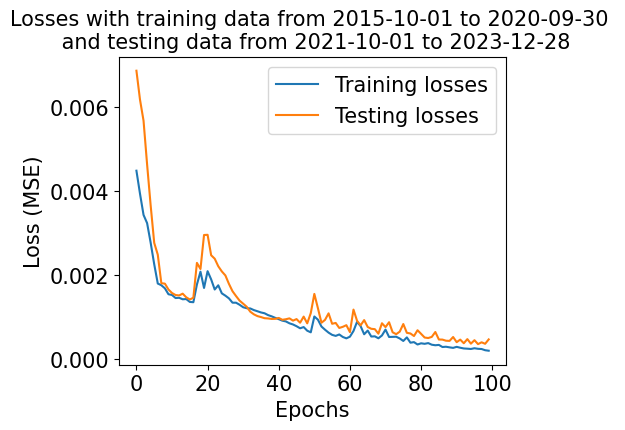

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(loss_train_flow, label='Training losses')
ax.plot(loss_test_flow, label='Testing losses')
ax.set(title=f'Losses with training data from {train_start} to {train_end} \n and testing data from {test_start} to {test_end}',
       ylabel='Loss (MSE)', xlabel='Epochs')
ax.legend(loc='upper right');


## Make predictions and get the hidden states for SAS arguments

In [23]:
flow_hidden_states = predict_dl(all_loader, flow_model_new.calculate_hidden_states)
Q_lstm = predict_dl(all_loader, flow_model_new)


# The transport model

## Get the transport model training data

In [13]:
# TODO: skip the initial days with sequence length used by LSTM model
df_cut = df.iloc[cutoff_length:]
dt = transport_params['transport_specs']['dt']
J, Q, ET, C_J, C_Q_J, time = get_transport_obs_fluxes(df_cut, watershed_name)
τ_max = J.size if transport_model.τ_max is None else transport_model.τ_max
sTmT_init = jnp.zeros([τ_max, 2])


In [ ]:
# SAS arguments
sas_Q_args, sas_ET_args = get_sas_inputs(flow_transport_coupling_type, Q, ET, flow_model_new, all_loader)
# sas_Q_args, sas_ET_args = get_sas_inputs(flow_transport_coupling_type, Q, ET, flow_model, all_loader)
    

In [19]:
# Inputs and outputs
mask = jnp.where(~jnp.isnan(C_Q_J))
x = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask]
y = C_Q_J[mask][:,None]

# Traing data
# During training, we run the model until the end of the training period
mask_train = mask[0][(mask[0]>train_start_ind) & (mask[0]<train_end_ind)]
x_train = [e[:train_end_ind] for e in x[:-1]] + [mask_train]
y_train = C_Q_J[mask_train][:,None]

# Test data
# During test, we run the model throughout the whole period but evaluate only on the test period
mask_test = mask[0][(mask[0]>test_start_ind) & (mask[0]<test_end_ind)]
x_test = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask_test]
y_test = C_Q_J[mask_test][:,None]

y_train.shape, y_test.shape


((1547, 1), (435, 1))

## Train the transport model

In [27]:
# Train the model
jax.clear_caches()
transport_model_new, loss_train_transport, loss_test_transport = train_transport_model(
    transport_model, train_config['epochs'], mse, optim, x_train, y_train, x_test, y_test
)


2025-03-05 16:05:42,885 - INFO - The loss of step 0: 0.04341369494795799
2025-03-05 16:06:15,670 - INFO - The loss of step 1: 0.043098900467157364
2025-03-05 16:06:36,074 - INFO - The loss of step 2: 0.042760126292705536
2025-03-05 16:06:42,059 - INFO - The loss of step 3: 0.04239954054355621
2025-03-05 16:06:48,023 - INFO - The loss of step 4: 0.042020298540592194
2025-03-05 16:06:54,003 - INFO - The loss of step 5: 0.04157321900129318
2025-03-05 16:06:59,984 - INFO - The loss of step 6: 0.041017014533281326
2025-03-05 16:07:05,978 - INFO - The loss of step 7: 0.04031684622168541
2025-03-05 16:07:11,976 - INFO - The loss of step 8: 0.039424050599336624
2025-03-05 16:07:17,962 - INFO - The loss of step 9: 0.03826608508825302
2025-03-05 16:07:23,954 - INFO - The loss of step 10: 0.03676336258649826
2025-03-05 16:07:29,957 - INFO - The loss of step 11: 0.034940071403980255
2025-03-05 16:07:35,969 - INFO - The loss of step 12: 0.03278617188334465
2025-03-05 16:07:41,987 - INFO - The loss 

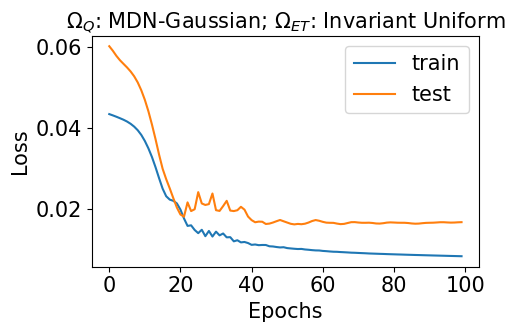

In [36]:
# Plot the loss
fig, ax = plt.subplots(1, 1, figsize=(5,3))
ax.plot(loss_train_transport, label='train')
ax.plot(loss_test_transport, label='test')
ax.set(xlabel='Epochs', ylabel='Loss', 
       title='$\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform')
ax.legend()


## Make predictions

In [37]:
# Run the trained model
sT, mT, mQETs, pQETs, mRs, C_Q = transport_model_new(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
df_cut['C_Q pred'] = C_Q


/tmp/ipykernel_1620601/2377562898.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cut['C_Q pred'] = C_Q


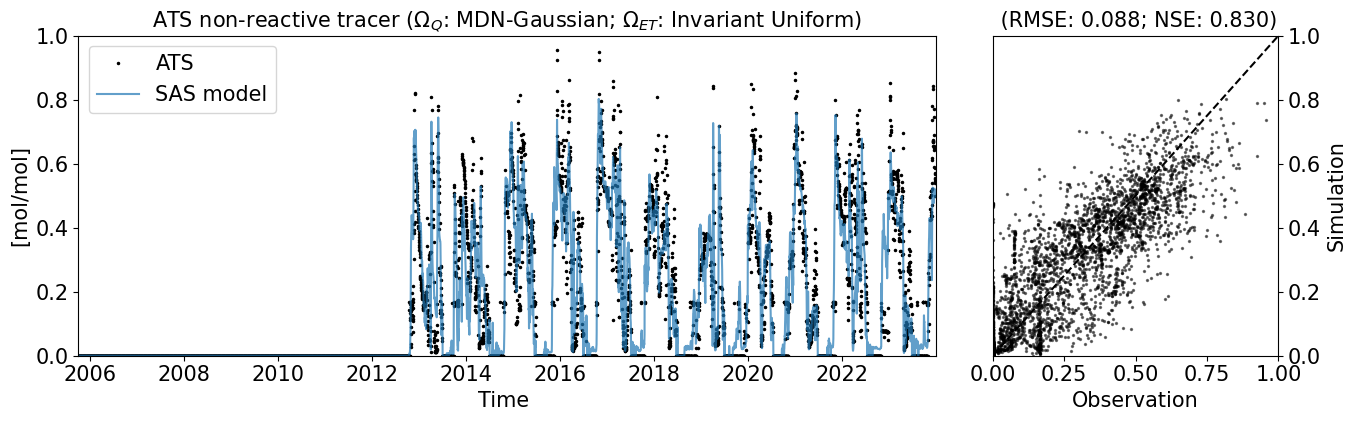

In [38]:
plot_timeseries_obs_1to1(
    obs=df_cut['C_Q'].values, sim=df_cut['C_Q pred'].values, lim=[0,1], timesteps=df_cut.index,
    varn='ATS non-reactive tracer ($\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform)',
    units='[mol/mol]', label_sim='SAS model', label_obs='ATS'
);


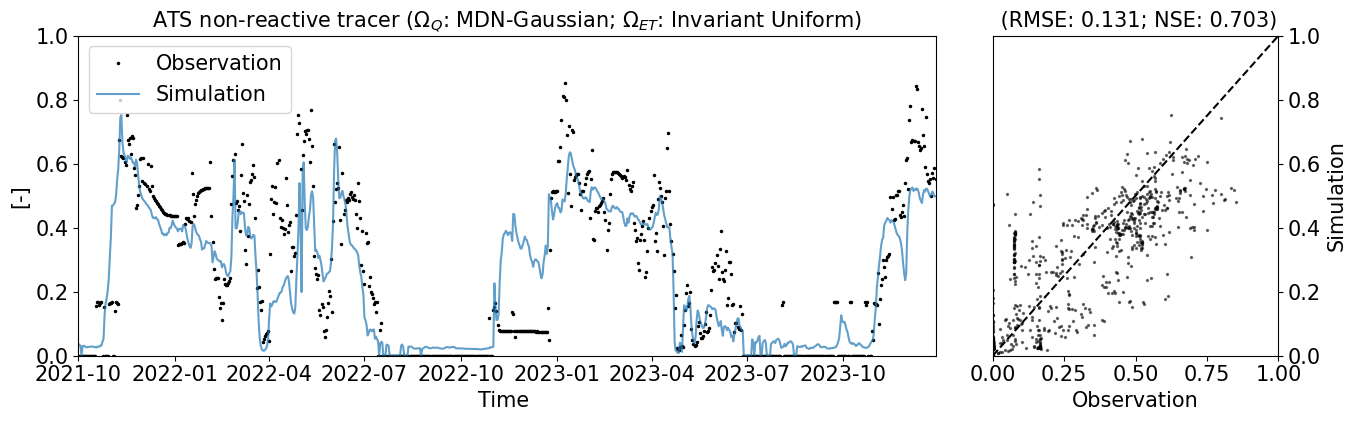

In [39]:
s, e = test_start, test_end
plot_timeseries_obs_1to1(
    obs=df_cut['C_Q'][s:e].values, sim=df_cut['C_Q pred'][s:e].values, lim=[0,1], 
    timesteps=df_cut[s:e].index,
    varn='ATS non-reactive tracer ($\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform)'
);


array([<Axes: title={'center': 'Q age distribution ()'}, ylabel='Age [Days]'>,
       <Axes: title={'center': 'ET age distribution ()'}, ylabel='Age [Days]'>],
      dtype=object)

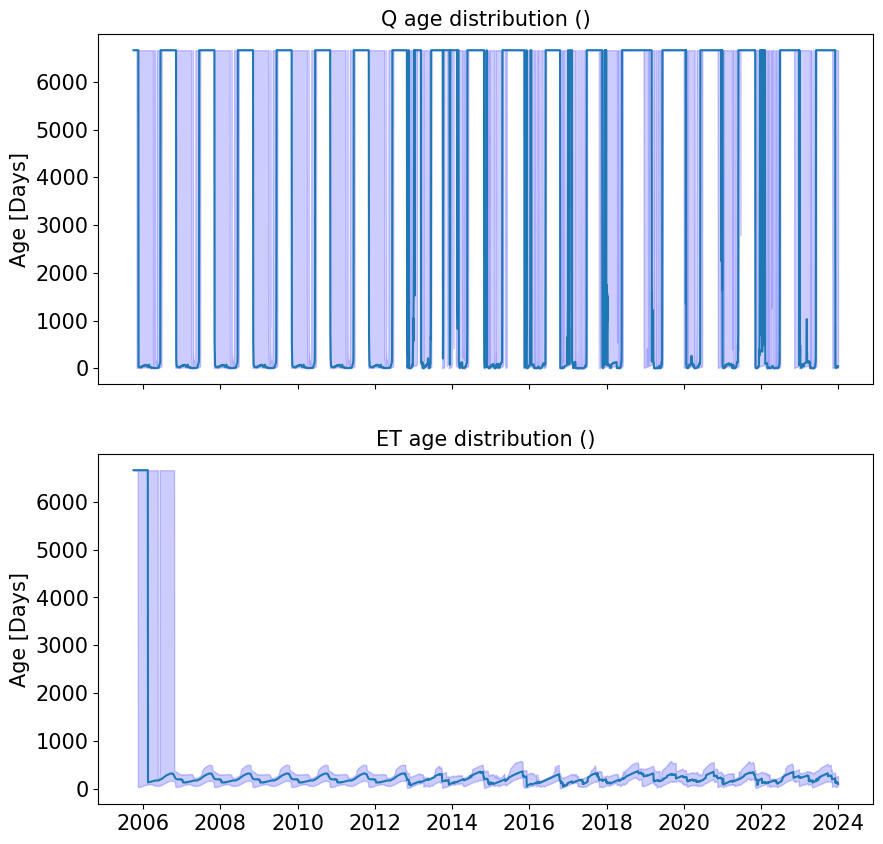

In [40]:
plot_PQET_quantile(pQETs, transport_params['transport_specs']['dt'], df_cut.index)


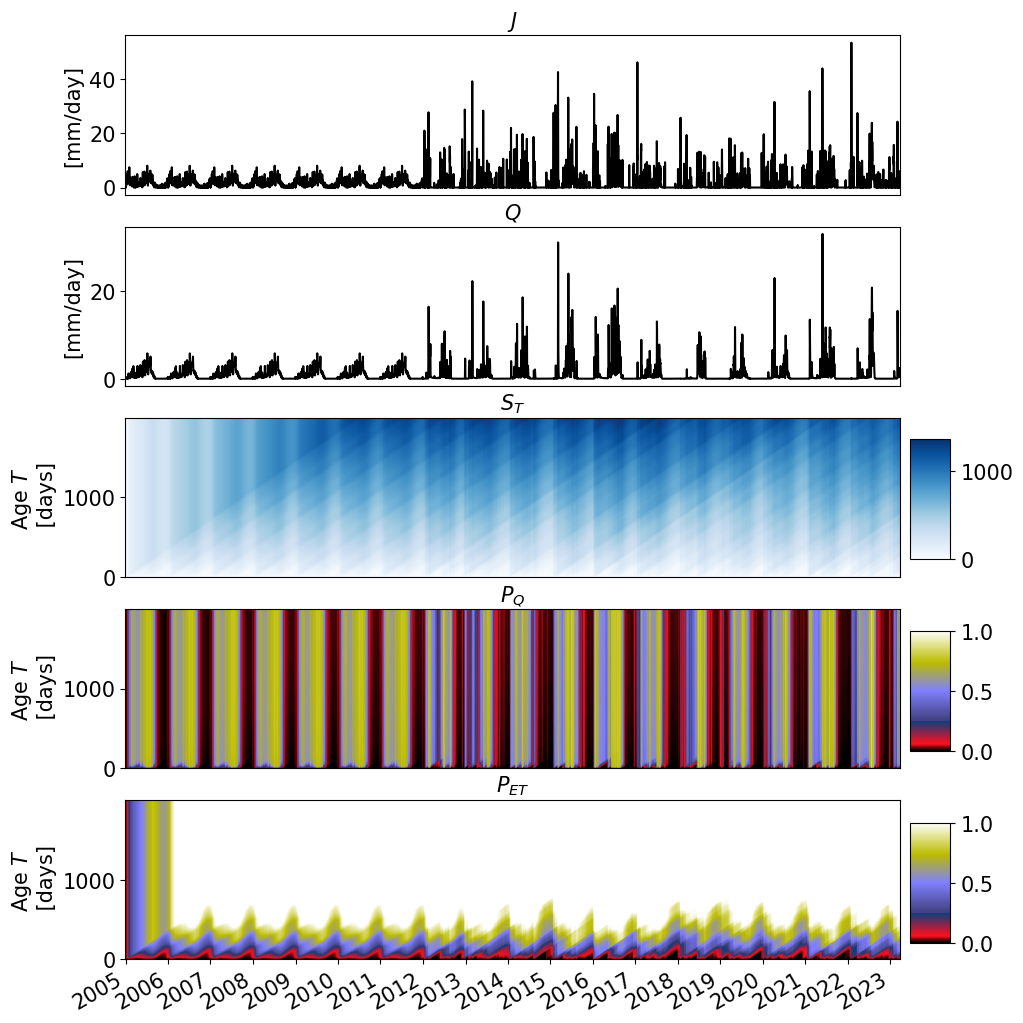

In [41]:
plot_PQET_ST(J, Q, sT, pQETs, dt, time, age_cut=2000);

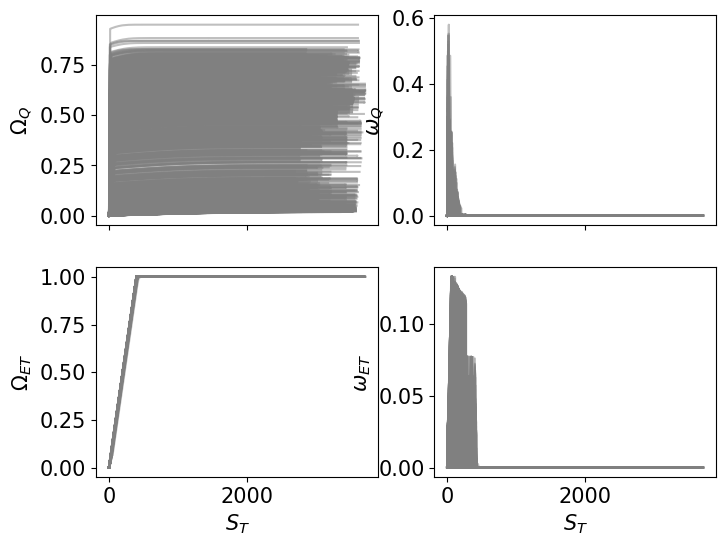

In [42]:
# Age distribution
axes = plot_PQET_ST2(sT, pQETs, dt, last_age_cut=2000, figsize=(8,6), label='')


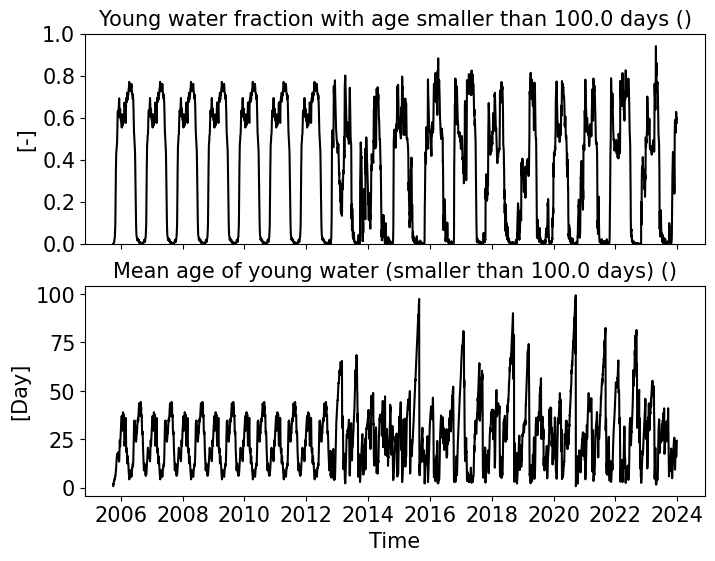

In [43]:
# Young water fraction in streamflow
plot_young_water(pQETs[...,0], time, dt=dt, cutoff_age=100);


# Save the models

In [ ]:
f_flow = f'flow_model_{model_label}.eqx'
f_transport = f'transport_model_{model_label}.eqx'
f_configs = f'configs-{model_label}.json'
dir_models = Path(f'models-{data_option}')


In [ ]:
# Save the overall configurations
configs = {
    "flow_configs": flow_params,
    "transport_configs": transport_params,
    "f_flow": f_flow,
    "f_transport": f_transport,
    "flow_loss": {
        "train": loss_train_flow.tolist(),
        "test": loss_test_flow.tolist()
    },
    "transport_loss": {
        "train": loss_train_transport.tolist(),
        "test": loss_test_transport.tolist()
    },
    "flow_dl_configs": flow_dl_config,
    "train_configs": train_config,
    "flow_transport_coupling_type": flow_transport_coupling_type,
    "f_data": "../" + f_data,
    "watershed_name": watershed_name
}

In [ ]:
# save_model(configs, flow_model_new, transport_model_new, f_configs, dir_models)